##### ML_Geely_Auto #####

In [ ]:
## 1.Import liabraries


import pandas as pd # data manipulation
import numpy as np # numerical operations
import seaborn as sns # data visualization
import matplotlib.pyplot as plt # plotting
from sklearn.metrics import r2_score, mean_squared_error # model evaluation
from sklearn.preprocessing import StandardScaler # feature scaling
from sklearn.cluster import KMeans # clustering algorithm
from sklearn.model_selection import train_test_split # data splitting
from sklearn.linear_model import LinearRegression # linear regression model
from sklearn.tree import DecisionTreeRegressor # decision tree regression model
from sklearn.ensemble import RandomForestRegressor # random forest regression model
from sklearn.metrics import mean_squared_error # mean squared error for model evaluation
from sklearn.impute import SimpleImputer # handling missing values
import statsmodels.api as sm # for statistical modeling
from sklearn.feature_selection import RFE # Recursive Feature Elimination for feature selection
from sklearn.linear_model import LinearRegression # Linear Regression model for RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF calculation for multicollinearity check
import warnings # to ignore warnings
warnings.filterwarnings('ignore')  # Ignore warnings for cleaner output

In [ ]:
## 2.Load DATASET

car_df=pd.read_csv("CarPrice_Assignment.csv")

In [ ]:
## 3.Show the first 5 rows of the dataset

car_df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
## 4. Show the Summary of the dataset

car_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [ ]:
## 5. Check for null values


car_df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [ ]:
## 6. Show the Names under the CarName column

car_df['CarName'].head()

0          alfa-romero giulia
1         alfa-romero stelvio
2    alfa-romero Quadrifoglio
3                 audi 100 ls
4                  audi 100ls
Name: CarName, dtype: str

In [ ]:
## 7. Remove the leading and trailing spaces from the CarName column

car_df['CarName'].str.strip()

0            alfa-romero giulia
1           alfa-romero stelvio
2      alfa-romero Quadrifoglio
3                   audi 100 ls
4                    audi 100ls
                 ...           
200             volvo 145e (sw)
201                 volvo 144ea
202                 volvo 244dl
203                   volvo 246
204                 volvo 264gl
Name: CarName, Length: 205, dtype: str

In [ ]:
## 8. Extracting the brand name from the CarName column and creating a new column called Brand

car_df['Brand']=car_df['CarName'].astype(str).apply(lambda x:x.split(' ')[0])

#show the first 5 rows of the CarName and Brand columns to verify the new column
print(car_df[['CarName','Brand']].head())

                    CarName        Brand
0        alfa-romero giulia  alfa-romero
1       alfa-romero stelvio  alfa-romero
2  alfa-romero Quadrifoglio  alfa-romero
3               audi 100 ls         audi
4                audi 100ls         audi


In [ ]:
## 9. Dropping the columns CarName and Car_ID as they are not needed for Analysis

car_df.drop(columns=['CarName','car_ID'],inplace=True)

In [ ]:
## 10. Data Understanding

car_df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [ ]:
## 11. Show the unique values in the Brand column to Understand the difference between the brands

print(car_df['Brand'].unique())

<StringArray>
['alfa-romero',        'audi',         'bmw',   'chevrolet',       'dodge',
       'honda',       'isuzu',      'jaguar',       'maxda',       'mazda',
       'buick',     'mercury',  'mitsubishi',      'Nissan',      'nissan',
     'peugeot',    'plymouth',     'porsche',    'porcshce',     'renault',
        'saab',      'subaru',      'toyota',     'toyouta',   'vokswagen',
  'volkswagen',          'vw',       'volvo']
Length: 28, dtype: str


In [ ]:
## 12. Data Cleaning

correction={'alfa-romero':'AlphaRomeo',
            'audi':'Audi',
            'bmw':'BMW',
            'chevrolet':'Chevrolet',
            'dodge':'Dodge',
            'honda':'Honda',
            'isuzu':'Isuzu',
            'jaguar':'Jaguar',
            'maxda':'Mazda',
            'mazda':'Mazda',
            'buick':'Buick',
            'mercury':'Mercedes',
            'mitsubishi':'Mitsubishi',
            'nissan': 'Nissan',
            'peugeot':'Peugeot',
            'porcshce': 'porsche',
            'toyouta':'toyota',
            'vokswagen':'volkswagen',
            'vw':'volkswagen'
            }

In [ ]:
## 13. Replacing the incorrect brand names with the correct ones using the replace function

car_df['Brand']=car_df['Brand'].replace(correction)

In [ ]:
## 14. Show the unique values in the Brand column to verify the changes
print(car_df['Brand'].unique())


<StringArray>
['AlphaRomeo',       'Audi',        'BMW',  'Chevrolet',      'Dodge',
      'Honda',      'Isuzu',     'Jaguar',      'Mazda',      'Buick',
   'Mercedes', 'Mitsubishi',     'Nissan',    'Peugeot',   'plymouth',
    'porsche',    'renault',       'saab',     'subaru',     'toyota',
 'volkswagen',      'volvo']
Length: 22, dtype: str


In [ ]:
# 15. Show the first 5 rows of the dataset to verify the changes
car_df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,AlphaRomeo
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,AlphaRomeo
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,AlphaRomeo
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,Audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,Audi


In [ ]:
## 15. Show the summary statistics of the dataset to understand the distribution of the data and identify any outliers or anomalies 

car_df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


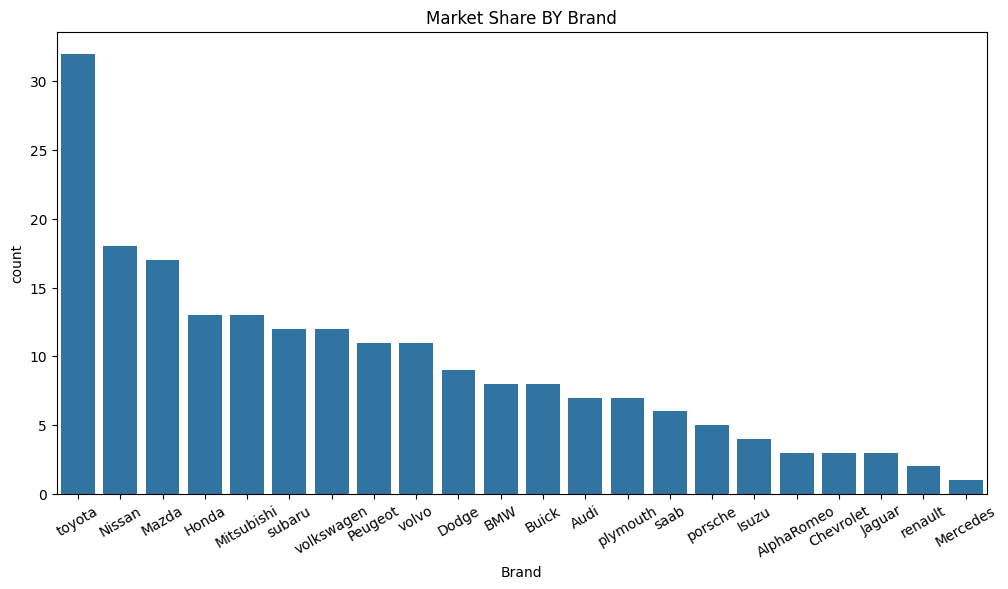

In [ ]:
## 16. Show the distribution of target variable Price using a histogram to understand the range and frequency of the prices in the dataset

plt.figure(figsize=(12,6))
sns.countplot(data=car_df,x='Brand',order=car_df['Brand'].value_counts().index)
plt.xticks(rotation=30)
plt.title('Market Share BY Brand')
plt.show()

(array([53., 51., 24., 20., 26.,  7.,  5.,  2.,  2.,  3.,  4.,  5.,  0.,
         2.,  1.]),
 array([ 5118.        ,  7803.46666667, 10488.93333333, 13174.4       ,
        15859.86666667, 18545.33333333, 21230.8       , 23916.26666667,
        26601.73333333, 29287.2       , 31972.66666667, 34658.13333333,
        37343.6       , 40029.06666667, 42714.53333333, 45400.        ]),
 <BarContainer object of 15 artists>)

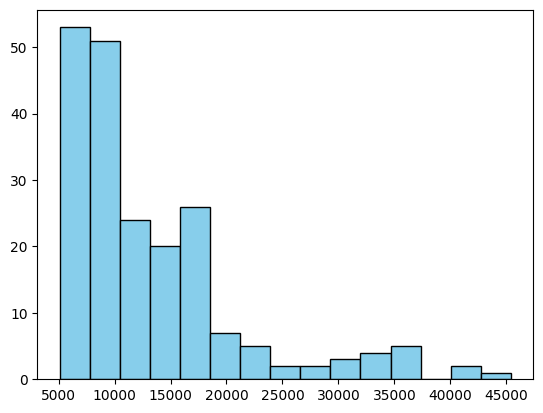

In [ ]:
## 16. Show the distribution of target variable Price using a histogram to understand the range and frequency of the prices in the dataset

plt.hist(car_df['price'], bins=15, edgecolor='black',color='skyblue')

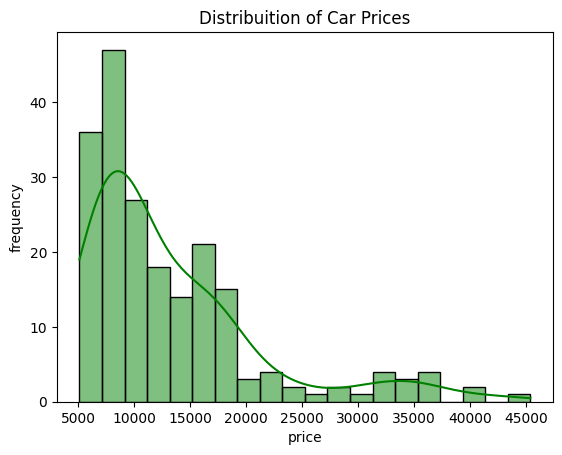

In [ ]:
## 16. Show the distribution of target variable Price using a histogram to understand the range and frequency of the prices in the dataset

sns.histplot(car_df['price'],kde=True, bins=20, edgecolor='black',color='green')
plt.title('Distribuition of Car Prices')
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

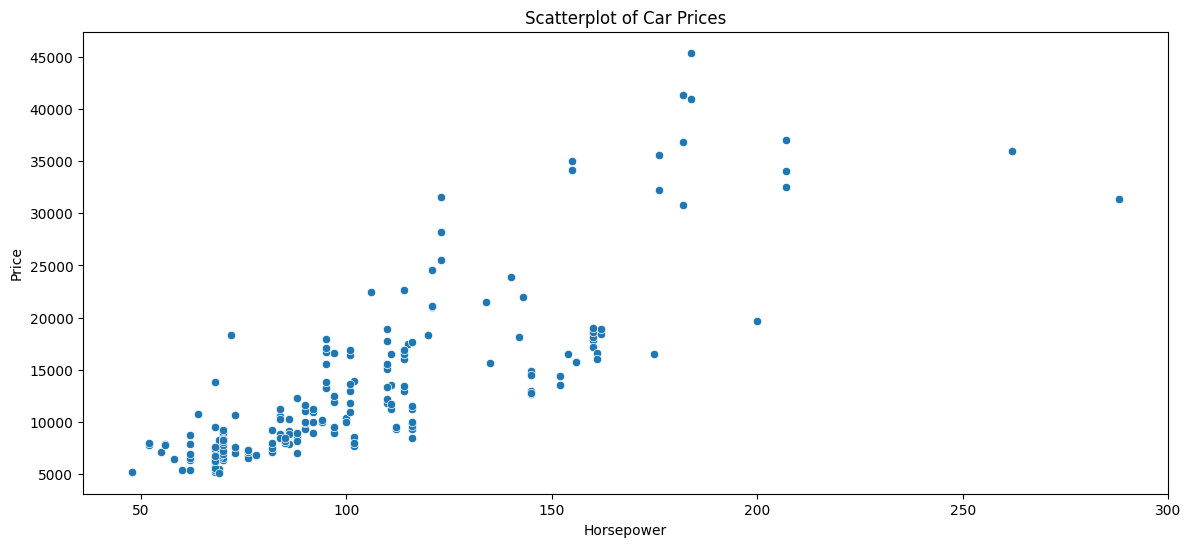

In [ ]:
# 17. Show the distribution of car prices by horsepower using a scatterplot
plt.figure(figsize=(14,6))
sns.scatterplot(data=car_df, x='horsepower', y='price')
plt.title('Scatterplot of Car Prices')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

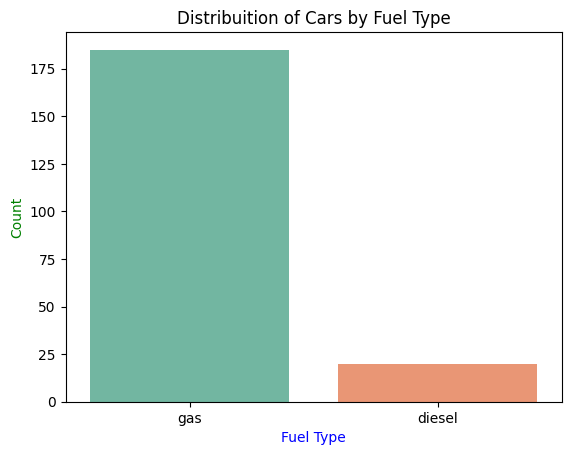

In [ ]:
# 18. Show the distribution of cars by fuel type using a countplot to understand the frequency of each fuel type in the dataset

sns.countplot(data=car_df,x='fueltype',palette='Set2')
plt.title('Distribuition of Cars by Fuel Type')
plt.xlabel('Fuel Type',color='blue')
plt.ylabel('Count',color='green')
plt.show()

In [ ]:
# 19. Show the distribution of cars by body style using a countplot to understand the frequency of each body style in the dataset
car_df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,AlphaRomeo
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,AlphaRomeo
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,AlphaRomeo
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,Audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,Audi


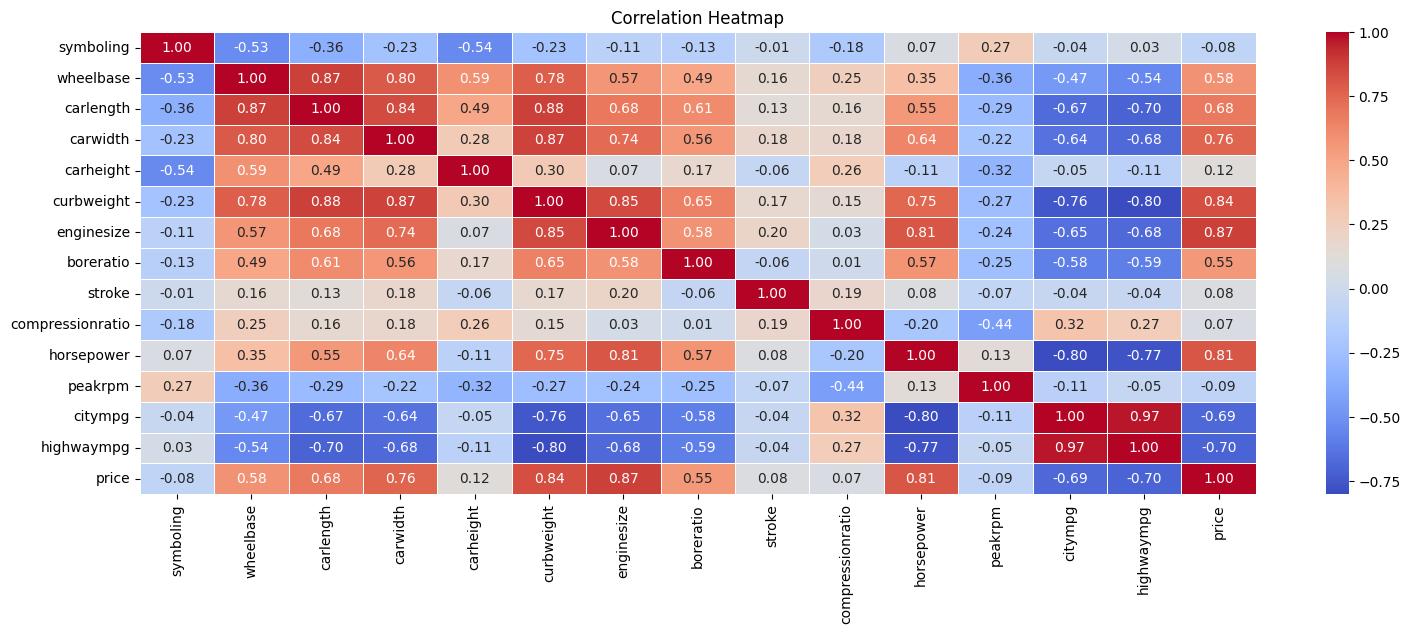

In [ ]:
# 20. Show the correlation between the numerical features in the dataset using a heatmap to identify any strong correlations that may exist between the features and the target variable price

plt.figure(figsize=(18,6))

#selecting only the numerical columns from the dataset to calculate the correlation matrix


numeric_cols=car_df.select_dtypes(include=['int64', 'float64'])

#creating a heatmap to visualize the correlation matrix of the numerical features in the dataset

sns.heatmap(numeric_cols.corr(),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# 21. Show the distribution of cars by body style using a countplot to understand the frequency of each body style in the dataset
car_df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,AlphaRomeo
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,AlphaRomeo
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,AlphaRomeo
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,Audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,Audi


In [ ]:
# 22. Show the unique values in the Brand column to understand the difference between the brands
print(car_df['Brand'].unique())


<StringArray>
['AlphaRomeo',       'Audi',        'BMW',  'Chevrolet',      'Dodge',
      'Honda',      'Isuzu',     'Jaguar',      'Mazda',      'Buick',
   'Mercedes', 'Mitsubishi',     'Nissan',    'Peugeot',   'plymouth',
    'porsche',    'renault',       'saab',     'subaru',     'toyota',
 'volkswagen',      'volvo']
Length: 22, dtype: str


In [ ]:
# 23. Show the distribution of cars by body style using a countplot to understand the frequency of each body style in the dataset
print(car_df['Brand'].unique())

<StringArray>
['AlphaRomeo',       'Audi',        'BMW',  'Chevrolet',      'Dodge',
      'Honda',      'Isuzu',     'Jaguar',      'Mazda',      'Buick',
   'Mercedes', 'Mitsubishi',     'Nissan',    'Peugeot',   'plymouth',
    'porsche',    'renault',       'saab',     'subaru',     'toyota',
 'volkswagen',      'volvo']
Length: 22, dtype: str


In [ ]:
# 24. Check for null values in the Brand column to identify any missing values that may need to be addressed before further analysis or modeling

print(car_df['Brand'].isnull().sum())

0


In [ ]:
# 25. Check for null values in the dataset to identify any missing values that may need to be addressed before further analysis or modeling

car_df.isnull().sum()

symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
Brand               0
dtype: int64

In [ ]:
## 26. Data Preprocessing

car_df['fueltype']=car_df['fueltype'].astype('category').cat.codes
car_df['aspiration']=car_df['aspiration'].astype('category').cat.codes
car_df['doornumber']=car_df['doornumber'].astype('category').cat.codes
car_df['enginetype']=car_df['enginetype'].astype('category').cat.codes
car_df['carbody']=car_df['carbody'].astype('category').cat.codes
car_df['drivewheel']=car_df['drivewheel'].astype('category').cat.codes
car_df['enginelocation']=car_df['enginelocation'].astype('category').cat.codes
car_df['enginetype']=car_df['enginetype'].astype('category').cat.codes
car_df['fuelsystem']=car_df['fuelsystem'].astype('category').cat.codes
car_df['cylindernumber']=car_df['cylindernumber'].astype('category').cat.codes
car_df['Brand']=car_df['Brand'].astype('category').cat.codes

In [ ]:
# 27. Show the distribution of cars by body style using a countplot to understand the frequency of each body style in the dataset
car_df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,13495.0,0
1,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,16500.0,0
2,1,1,0,1,2,2,0,94.5,171.2,65.5,...,5,2.68,3.47,9.0,154,5000,19,26,16500.0,0
3,2,1,0,0,3,1,0,99.8,176.6,66.2,...,5,3.19,3.40,10.0,102,5500,24,30,13950.0,1
4,2,1,0,0,3,0,0,99.4,176.6,66.4,...,5,3.19,3.40,8.0,115,5500,18,22,17450.0,1


In [ ]:
## 28. Separate the features and target variable from the dataset to prepare for modeling
X=car_df.drop(columns=['price'])
X.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,Brand
0,3,1,0,1,0,2,0,88.6,168.8,64.1,...,130,5,3.47,2.68,9.0,111,5000,21,27,0
1,3,1,0,1,0,2,0,88.6,168.8,64.1,...,130,5,3.47,2.68,9.0,111,5000,21,27,0
2,1,1,0,1,2,2,0,94.5,171.2,65.5,...,152,5,2.68,3.47,9.0,154,5000,19,26,0
3,2,1,0,0,3,1,0,99.8,176.6,66.2,...,109,5,3.19,3.40,10.0,102,5500,24,30,1
4,2,1,0,0,3,0,0,99.4,176.6,66.4,...,136,5,3.19,3.40,8.0,115,5500,18,22,1


In [ ]:
## 29. Show the target variable to understand the values that we are trying to predict
Y=car_df['price']
Y.head()

0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

In [ ]:
## 30. Split the dataset into training and testing sets to evaluate the performance of the model on unseen data
X_train, X_test, Y_train, Y_test =train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:

##31.1 STEP : Scaling (Only on  Numerical Columns)
 
scaler = StandardScaler()

#including only the numeric columns for scaling
num_vars = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 
            'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 
            'peakrpm', 'citympg', 'highwaympg', 'price']

#fit aur transform the training data
# Note: Agar y_train alg se hai, toh 'price' ko list se hata dein
X_train[num_vars[:-1]] = scaler.fit_transform(X_train[num_vars[:-1]])

# Test data ko sirf transform karein
X_test[num_vars[:-1]] = scaler.transform(X_test[num_vars[:-1]])


In [ ]:
## STEP 31.2: RFE (SELECT Top 15 Features )

lm = LinearRegression()
lm.fit(X_train, Y_train)

rfe = RFE(lm, n_features_to_select=15)             
rfe = rfe.fit(X_train, Y_train)

# Filtered X_train with only 15 best columns
col = X_train.columns[rfe.support_]
X_train_rfe = X_train[col]




In [ ]:

# STEP 31.3: Statsmodels OLS (P-value check)
# 1. Constant add



X_train_sm = sm.add_constant(X_train_rfe)

#  THE FIX: Data types ko explicitly float banayein
X_train_sm = X_train_sm.astype(float)
Y_train = Y_train.astype(float)

#  THE FIX: Index reset karein taaki X_train aur y_train aapas mein miss-match na hon
X_train_sm = X_train_sm.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# Ab OLS model fit karein
lm_model = sm.OLS(Y_train, X_train_sm).fit()

print("--- OLS MODEL SUMMARY ---")
print(lm_model.summary())



--- OLS MODEL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     79.99
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.99e-63
Time:                        12:33:13   Log-Likelihood:                -1519.7
No. Observations:                 164   AIC:                             3071.
Df Residuals:                     148   BIC:                             3121.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const         

In [ ]:

# STEP 31.4: VIF Calculation (Multicollinearity check)

vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)

print("\n--- VIF SCORE ---")
print(vif)





--- VIF SCORE ---
            Features    VIF
0           fueltype  32.31
3            carbody  22.95
13           citympg  22.71
14        highwaympg  20.18
8         curbweight  15.59
6          carlength   9.62
5          wheelbase   6.67
9         enginesize   6.38
11  compressionratio   5.31
7           carwidth   5.14
2         doornumber   4.30
1         aspiration   1.84
12           peakrpm   1.76
4     enginelocation   1.65
10            stroke   1.24


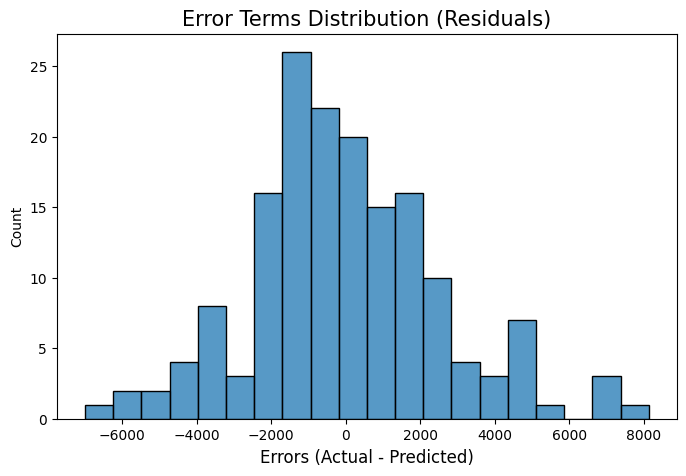

In [ ]:

# STEP 31.5: Residual Analysis (Error Plot)

Y_train_pred = lm_model.predict(X_train_sm)
res = (Y_train - Y_train_pred)

plt.figure(figsize=(8,5))
sns.histplot(res, bins = 20)
plt.title('Error Terms Distribution (Residuals)', fontsize=15)
plt.xlabel('Errors (Actual - Predicted)', fontsize=12)
plt.show()




In [ ]:

# STEP 31.6: Final Prediction on Test Data

# Test data mein bhi sirf wo 15 columns rakhein aur constant add karein
X_test_rfe = X_test[col]
X_test_sm = sm.add_constant(X_test_rfe)

# Predict
Y_test_pred = lm_model.predict(X_test_sm)

# R-squared Score
test_r2 = r2_score(Y_test, Y_test_pred)
print(f"\nFINAL TEST R-SQUARED SCORE: {test_r2:.4f}")



from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Constant column ko hatakar VIF calculate karte hain
X_train_vif = X_train_sm.drop('const', axis=1)

vif = pd.DataFrame()
vif['Features'] = X_train_vif.columns
vif['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)

print(vif)


FINAL TEST R-SQUARED SCORE: 0.7979
            Features    VIF
0           fueltype  32.31
3            carbody  22.95
13           citympg  22.71
14        highwaympg  20.18
8         curbweight  15.59
6          carlength   9.62
5          wheelbase   6.67
9         enginesize   6.38
11  compressionratio   5.31
7           carwidth   5.14
2         doornumber   4.30
1         aspiration   1.84
12           peakrpm   1.76
4     enginelocation   1.65
10            stroke   1.24


In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('fueltype',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     86.15
Date:                Fri, 15 May 2026   Prob (F-statistic):           5.81e-64
Time:                        12:33:15   Log-Likelihood:                -1519.8
No. Observations:                 164   AIC:                             3070.
Df Residuals:                     149   BIC:                             3116.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              1.62e+04   1169.899  

In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('aspiration',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     93.12
Date:                Fri, 15 May 2026   Prob (F-statistic):           7.21e-65
Time:                        12:33:15   Log-Likelihood:                -1520.0
No. Observations:                 164   AIC:                             3068.
Df Residuals:                     150   BIC:                             3111.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.622e+04   1167.217  

In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('curbweight',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     100.4
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.50e-65
Time:                        12:33:15   Log-Likelihood:                -1520.8
No. Observations:                 164   AIC:                             3068.
Df Residuals:                     151   BIC:                             3108.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.623e+04   1169.216  

In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('carlength',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     109.3
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.48e-66
Time:                        12:33:15   Log-Likelihood:                -1521.5
No. Observations:                 164   AIC:                             3067.
Df Residuals:                     152   BIC:                             3104.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.628e+04   1169.029  

In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('doornumber',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     118.8
Date:                Fri, 15 May 2026   Prob (F-statistic):           7.54e-67
Time:                        12:33:16   Log-Likelihood:                -1522.8
No. Observations:                 164   AIC:                             3068.
Df Residuals:                     153   BIC:                             3102.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.498e+04    831.577  

In [ ]:
# 1. Drop the feature
X_train_rfe = X_train_rfe.drop('highwaympg',axis=1)

# 2. Reset indices for both to ensure they match perfectly (0, 1, 2...)
X_train_rfe = X_train_rfe.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

# 3. Add the constant and fit
X_train_sm = sm.add_constant(X_train_rfe)
lr_model = sm.OLS(Y_train, X_train_sm).fit()

# 4. Success check
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     132.5
Date:                Fri, 15 May 2026   Prob (F-statistic):           7.57e-68
Time:                        12:33:16   Log-Likelihood:                -1523.0
No. Observations:                 164   AIC:                             3066.
Df Residuals:                     154   BIC:                             3097.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.494e+04    827.146  

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Constant column ko hatakar VIF calculate karte hain
X_train_vif = X_train_sm.drop('const', axis=1)

vif = pd.DataFrame()
vif['Features'] = X_train_vif.columns
vif['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)

print(vif)

           Features   VIF
3          carwidth  4.53
8           citympg  3.19
4        enginesize  3.17
2         wheelbase  3.04
6  compressionratio  1.90
7           peakrpm  1.65
1    enginelocation  1.48
5            stroke  1.14
0           carbody  1.05


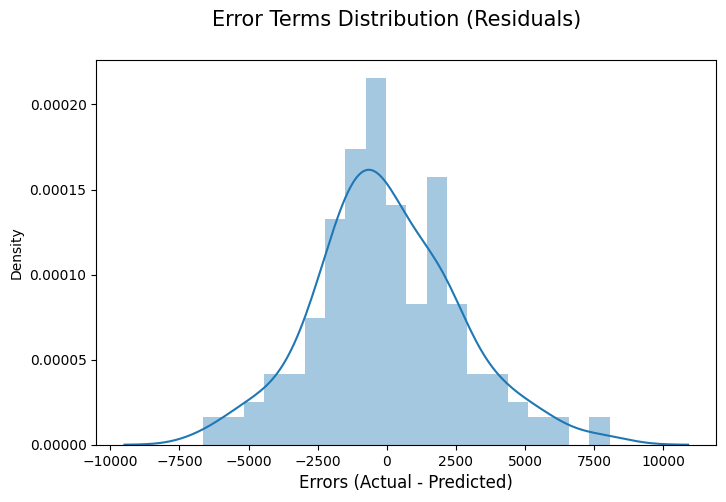


 FINAL TEST R-SQUARED SCORE: 0.8012 


In [ ]:


# ---------------------------------------------------------
# STEP 1: RESIDUAL ANALYSIS (Error Plot)
# ---------------------------------------------------------
# Train data par predictions nikaalein
Y_train_pred = lr_model.predict(X_train_sm)
res = (Y_train - Y_train_pred)

# Plot the histogram of errors
fig = plt.figure(figsize=(8,5))
sns.distplot(res, bins=20)
fig.suptitle('Error Terms Distribution (Residuals)', fontsize=15)
plt.xlabel('Errors (Actual - Predicted)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# STEP 2: FINAL TEST SCORE (Testing on unseen data)
# ---------------------------------------------------------
# 1. Jo columns final model mein bache hain, sirf unhe Test data mein rakhein
final_columns = X_train_sm.drop('const', axis=1).columns
X_test_final = X_test[final_columns]

# 2. Test data mein constant add karein
X_test_sm = sm.add_constant(X_test_final)

# 3. Test data par predictions karein
Y_test_pred = lr_model.predict(X_test_sm)

# 4. Final R-squared test score print karein
final_test_score = r2_score(Y_test, Y_test_pred)
print(f"\n FINAL TEST R-SQUARED SCORE: {final_test_score:.4f} ")

In [ ]:


# R-squared Score that i got after final model building and testing on unseen data
final_test_score = r2_score(Y_test, Y_test_pred)

#print final R-squared score

print(f" FINAL TEST R-SQUARED SCORE: {final_test_score:.4f}")

# To calculate MSE and RMSE

mse = mean_squared_error(Y_test, Y_test_pred)
rmse = np.sqrt(mse)

# print MSE and RMSE

print(f" Mean Squared Error (MSE): {mse:.2f}")
print(f" Root Mean Squared Error (RMSE): {rmse:.2f}")

 FINAL TEST R-SQUARED SCORE: 0.8012
 Mean Squared Error (MSE): 15691294.14
 Root Mean Squared Error (RMSE): 3961.22


In [ ]:

# BONUS: DECISION TREE REGRESSOR


from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. To Make Decision Tree Model 
# Note: max_depth=5 note: i have taken max_depth=5 to prevent overfitting, you can experiment with this value to see how it affects the model's performance
dt_model = DecisionTreeRegressor(max_depth=5, random_state=100)

# 2. To tran model we can use original X_train and Y_train (without RFE or OLS)
dt_model.fit(X_train, Y_train)

# 3. predict on test data
Y_test_pred_dt = dt_model.predict(X_test)

# 4. get scores
dt_r2_score = r2_score(Y_test, Y_test_pred_dt)
dt_mse = mean_squared_error(Y_test, Y_test_pred_dt)
dt_rmse = np.sqrt(dt_mse)

# 5. print results
print("--- DECISION TREE RESULTS ---")
print(f"R-Squared Score : {dt_r2_score:.4f}")
print(f"MSE             : {dt_mse:.2f}")
print(f"RMSE            : {dt_rmse:.2f}")

--- DECISION TREE RESULTS ---
R-Squared Score : 0.8873
MSE             : 8894079.46
RMSE            : 2982.29


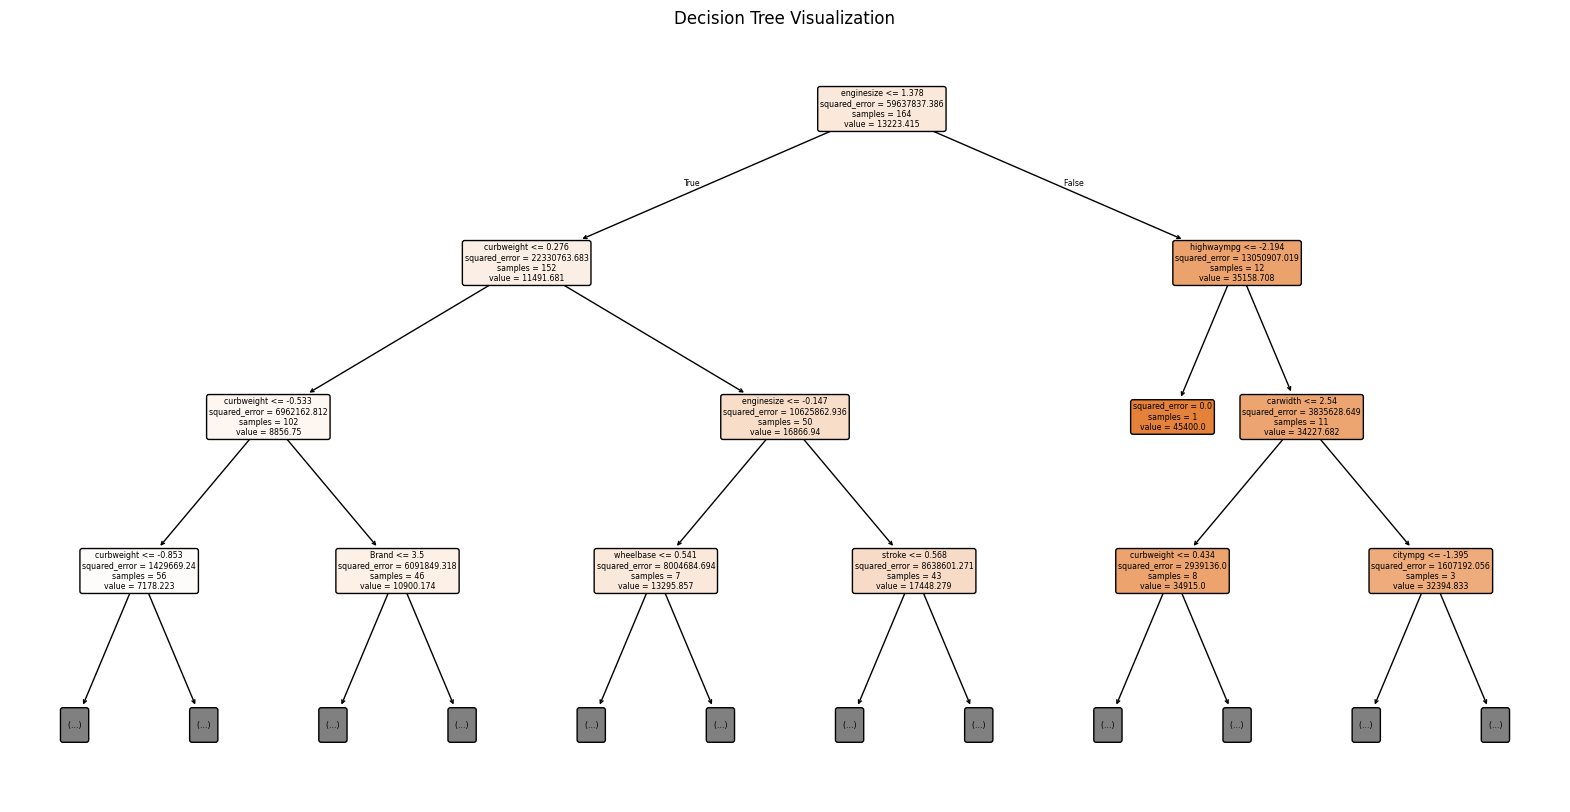

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train.columns, filled=True, rounded=True, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

# Final Conclusion: #

In this project, both Linear Regression  and Decision Tree models were built to predict car prices. The Decision Tree Regressor outperformed the Linear Regression model, achieving a higher Test R-squared (0.8873 vs 0.8012) and a significantly lower RMSE (2982 vs 3961). This indicates that the car price dataset contains complex, non-linear relationships and feature interactions that a tree-based algorithm captures much more effectively than a standard linear algorithm.

In [ ]:


## make a dataframe for powerbi with actual price, predictions and errors 
powerbi_df = X_test.copy()

# add actual price and predictions to the dataframe
powerbi_df['Price'] = Y_test_pred
powerbi_df['Linear_Prediction'] = Y_test_pred
powerbi_df['Tree_Prediction'] = Y_test_pred_dt

#find errors using actual price and predictions
powerbi_df['Linear_Error'] = powerbi_df['Price'] - powerbi_df['Linear_Prediction']
powerbi_df['Tree_Error'] = powerbi_df['Price'] - powerbi_df['Tree_Prediction']

# save the dataframe as a CSV file for PowerBI
powerbi_df.to_csv("Car_Price_PowerBI_Data.csv", index=False)

print("Data successfully saved as 'Car_Price_PowerBI_Data.csv' ! ")

Data successfully saved as 'Car_Price_PowerBI_Data.csv' ! 


In [ ]:
#now we will add the categorical labels back to the powerbi_df for better visualization in PowerBI
df_orig = pd.read_csv('CarPrice_Assignment.csv') 

# 2. Brand name nikalein (Kyunki ye encoded data mein nahi tha)
df_orig['Brand'] = df_orig['CarName'].apply(lambda x: x.split(' ')[0])

correction={'alfa-romero':'AlphaRomeo',
            'audi':'Audi',
            'bmw':'BMW',
            'chevrolet':'Chevrolet',
            'dodge':'Dodge',
            'honda':'Honda',
            'isuzu':'Isuzu',
            'jaguar':'Jaguar',
            'maxda':'Mazda',
            'mazda':'Mazda',
            'buick':'Buick',
            'mercury':'Mercedes',
            'mitsubishi':'Mitsubishi',
            'nissan': 'Nissan',
            'peugeot':'Peugeot',
            'porcshce': 'porsche',
            'toyouta':'toyota',
            'vokswagen':'volkswagen',
            'vw':'volkswagen'
            }
df_orig['Brand']=df_orig['Brand'].replace(correction)

# 3. we will restore the original categorical columns in the powerbi_df for better visualization in PowerBI
cols_to_restore = ['Brand', 'fueltype', 'aspiration', 'carbody', 'drivewheel', 
                  'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

# 4. Restore the original categorical columns
for col in cols_to_restore:
    #we will use the index of X_test to fetch the original text (Labels) from df_orig and put it in powerbi_df
    powerbi_df[col] = df_orig.loc[X_test.index, col].values

# 5. now save the final file with labels for PowerBI
powerbi_df.to_csv("Car_Price_Final_Labels.csv", index=False)
print("Done! Check the 'Car_Price_Final_Labels.csv' file, you should see original labels like 'Gas', 'Sedan', 'BMW' etc. instead of encoded numbers. ")

NameError: name 'pd' is not defined